In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. 强制使用 CPU
device = torch.device("cpu")

# 2. 定义数据增强（迁移学习数据准备）
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. 下载数据集 (使用 torchvision 内置函数)

train_set = datasets.GTSRB(root='./data', split='train', download=True, transform=data_transforms['train'])
test_set = datasets.GTSRB(root='./data', split='test', download=True, transform=data_transforms['test'])

# 为了让 CPU 跑得动，从 5万张图中抽取 20% 进行实验
indices = torch.arange(len(train_set))
train_sub_indices = indices[::5] # 每隔5张取一张
train_subset = Subset(train_set, train_sub_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"数据准备完成！训练样本数: {len(train_subset)}, 测试样本数: {len(test_set)}")

数据准备完成！训练样本数: 5328, 测试样本数: 12630


In [5]:

try:
    # 尝试新版写法
    model = models.mobilenet_v2(weights=models.MobileNetV2_Weights.IMAGENET1K_V1)
except AttributeError:
    # 如果报错，说明是旧版，使用传统写法
    model = models.mobilenet_v2(pretrained=True)

for param in model.parameters():
    param.requires_grad = False
    
for param in model.features[-3:].parameters():
    param.requires_grad = True

# 修改分类头：GTSRB 有 43 个类别
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_ftrs, 43) 
)

model = model.to(device)
print("模型加载并修改成功！")

模型加载并修改成功！


In [6]:
#优化器：因为解冻了部分层，给不同的层设置不同的学习率
# 特征层用极小的学习率(1e-5)微调，分类头用大学习率(1e-3)猛练
optimizer = optim.AdamW([
    {'params': model.features[-3:].parameters(), 'lr': 1e-5},  # 这里的 param 慢慢学
    {'params': model.classifier[1].parameters(), 'lr': 0.001}  # 这里的 param 快快学
], weight_decay=1e-4)

# 使用标签平滑损失
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 余弦退火学习率调度器
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [7]:
import time

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    acc = 100. * correct / total
    print(f'Epoch {epoch} | Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.2f}%')
    return running_loss/len(train_loader), acc

# 开始训练（在 CPU 上 10 个 Epoch ）
train_losses = []
train_accs = []
for epoch in range(15):
    loss, acc = train_one_epoch(epoch)
    train_losses.append(loss)
    train_accs.append(acc)

Epoch 0 | Loss: 2.7586 | Acc: 30.50%
Epoch 1 | Loss: 2.2505 | Acc: 45.36%
Epoch 2 | Loss: 2.1151 | Acc: 50.71%
Epoch 3 | Loss: 2.0289 | Acc: 53.34%
Epoch 4 | Loss: 1.9929 | Acc: 55.56%
Epoch 5 | Loss: 1.9167 | Acc: 57.36%
Epoch 6 | Loss: 1.8811 | Acc: 58.90%
Epoch 7 | Loss: 1.8409 | Acc: 60.23%
Epoch 8 | Loss: 1.7902 | Acc: 63.12%
Epoch 9 | Loss: 1.7765 | Acc: 62.07%
Epoch 10 | Loss: 1.7650 | Acc: 62.78%
Epoch 11 | Loss: 1.7402 | Acc: 64.40%
Epoch 12 | Loss: 1.7130 | Acc: 65.17%
Epoch 13 | Loss: 1.7009 | Acc: 65.54%
Epoch 14 | Loss: 1.7045 | Acc: 65.11%


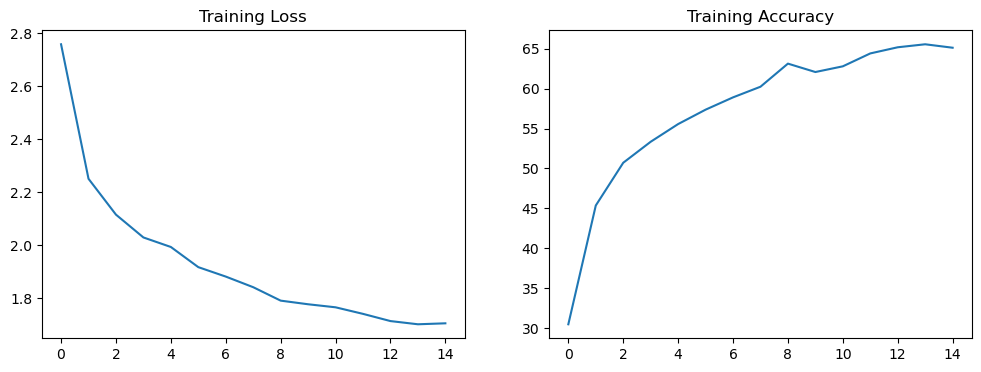

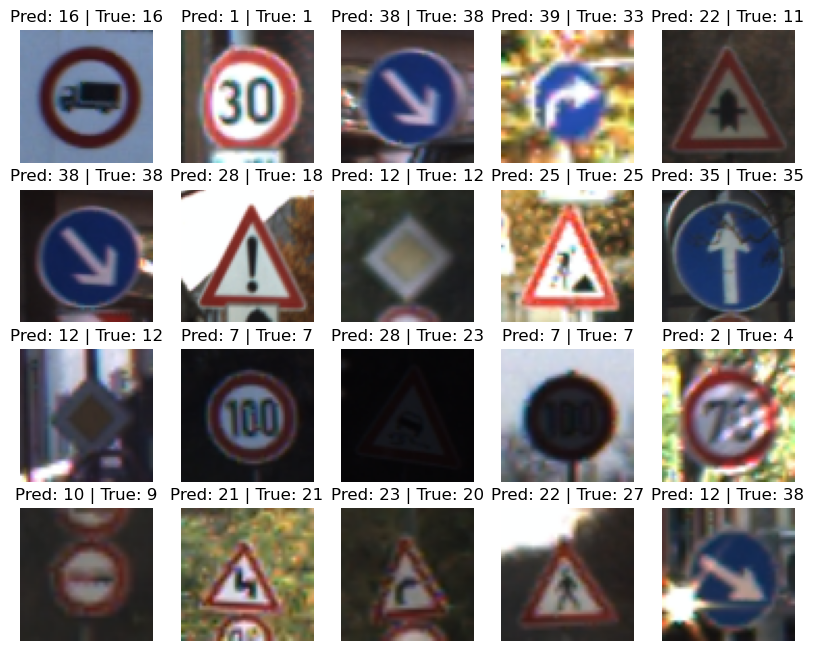

In [14]:
# 1. 绘制训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Accuracy')
plt.title('Training Accuracy')
plt.show()

# 2. 随机预测展示
model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(5, 5, i+1)
    # 反归一化以正常显示图片
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Pred: {predicted[i].item()} | True: {labels[i].item()}")
    plt.axis('off')
plt.show()